In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

import warnings
warnings.filterwarnings('ignore')

# Download the beverage sales dataset
path = kagglehub.dataset_download("sebastianwillmann/beverage-sales")
print("Dataset downloaded at:", path)

# List files to find the exact CSV name
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

# Load into a Pandas DataFrame
df = pd.read_csv(os.path.join(path, csv_file))

# Display the first 5 rows and basic info
display(df.head())
print("\n--- Dataset Info ---")
df.info()

100%|██████████| 119M/119M [00:01<00:00, 86.7MB/s]

Extracting files...


Dataset downloaded at: /root/.cache/kagglehub/datasets/sebastianwillmann/beverage-sales/versions/1


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Order_ID       object 
 1   Customer_ID    object 
 2   Customer_Type  object 
 3   Product        object 
 4   Category       object 
 5   Unit_Price     float64
 6   Quantity       int64  
 7   Discount       float64
 8   Total_Price    float64
 9   Region         object 
 10  Order_Date     object 
dtypes: float64(3), int64(1), object(7)
memory usage: 755.3+ MB


--- Missing Values ---
Order_ID         0
Customer_ID      0
Customer_Type    0
Product          0
Category         0
Unit_Price       0
Quantity         0
Discount         0
Total_Price      0
Region           0
Order_Date       0
dtype: int64


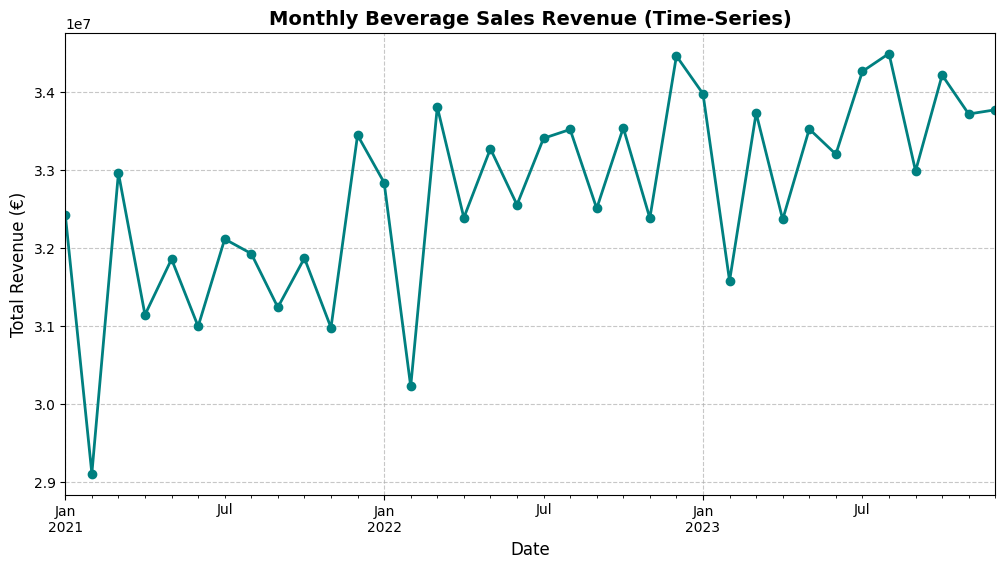

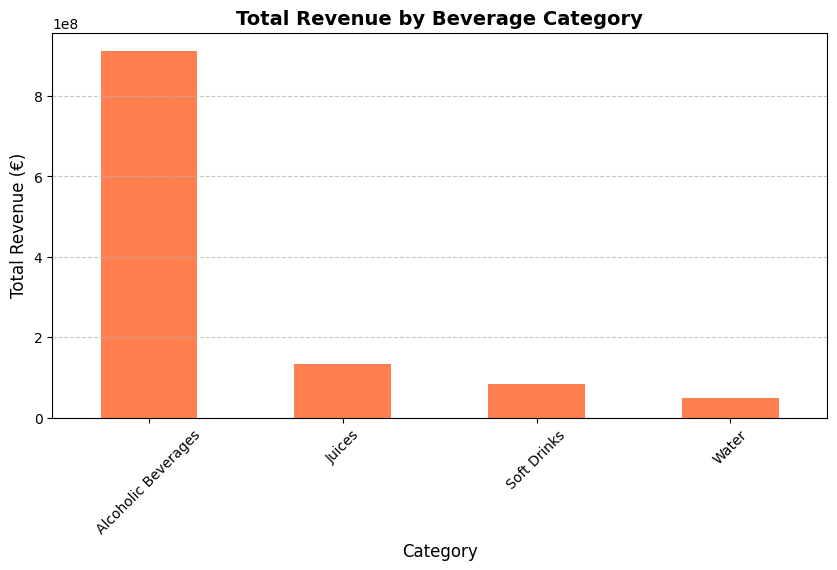

In [2]:
# ==========================================
# Step 2: Data Cleaning & Time-Series EDA
# ==========================================

# 1. Convert Order_Date to proper datetime object
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# 2. Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# 3. Drop any rows with missing values to keep our dataset clean
df.dropna(inplace=True)

# 4. Time Series: Aggregate sales by month to spot seasonality
# Using 'ME' (Month End) which is the updated standard in Pandas
monthly_sales = df.resample('ME', on='Order_Date')['Total_Price'].sum()

# Plot 1: Monthly Revenue Trend
plt.figure(figsize=(12, 6))
monthly_sales.plot(color='teal', marker='o', linewidth=2)
plt.title('Monthly Beverage Sales Revenue (Time-Series)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue (€)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Behavioral EDA: Revenue by Category
# Using groupby instead of seaborn for speed on 9M rows
category_sales = df.groupby('Category')['Total_Price'].sum().sort_values(ascending=False)

# Plot 2: Top Revenue Categories
plt.figure(figsize=(10, 5))
category_sales.plot(kind='bar', color='coral')
plt.title('Total Revenue by Beverage Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Revenue (€)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Business Insights: Customer Segment Summary ---


,Customer_Count,Avg_Revenue,Avg_Quantity,Avg_Discount
Cluster,,,,
0,1882,231057.13,43891.66,0.08
1,6437,42731.33,7202.20,0.00
2,1681,277674.06,47160.29,0.08


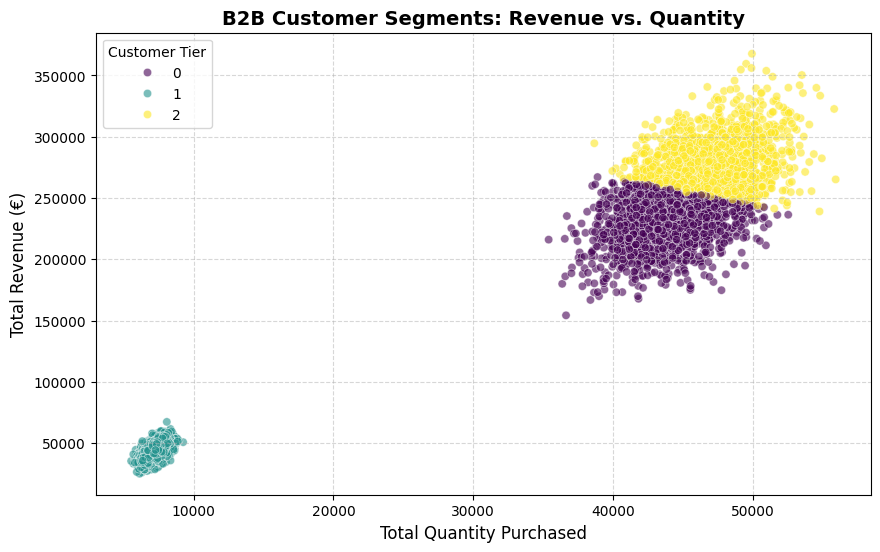

In [3]:
# ==========================================
# Step 3: K-Means Clustering (Customer Segmentation)
# ==========================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Aggregate data by Customer to prevent RAM crashes and build business profiles
customer_data = df.groupby('Customer_ID').agg(
    Total_Revenue=('Total_Price', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Average_Discount=('Discount', 'mean')
).reset_index()

# 2. Select features for clustering
features = customer_data[['Total_Revenue', 'Total_Quantity', 'Average_Discount']]

# 3. Scale the features (Standardization is required for K-Means)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 4. Apply K-Means (Assuming 3 distinct customer tiers for our B2B model)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(scaled_features)

# 5. Analyze the Clusters to understand what each segment represents
cluster_summary = customer_data.groupby('Cluster').agg(
    Customer_Count=('Customer_ID', 'count'),
    Avg_Revenue=('Total_Revenue', 'mean'),
    Avg_Quantity=('Total_Quantity', 'mean'),
    Avg_Discount=('Average_Discount', 'mean')
).round(2)

print("\n--- Business Insights: Customer Segment Summary ---")
display(cluster_summary)

# 6. Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_data,
    x='Total_Quantity',
    y='Total_Revenue',
    hue='Cluster',
    palette='viridis',
    alpha=0.6
)
plt.title('B2B Customer Segments: Revenue vs. Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Purchased', fontsize=12)
plt.ylabel('Total Revenue (€)', fontsize=12)
plt.legend(title='Customer Tier')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [4]:
# ==========================================
# Step 4: Logistic Regression (Classification)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# 1. Sample the dataset to prevent Colab RAM crashes during get_dummies
df_sample = df.sample(n=200000, random_state=42)

# 2. Create the Target Variable: 1 if "High Value", 0 if "Normal"
median_price = df_sample['Total_Price'].median()
df_sample['High_Value_Order'] = (df_sample['Total_Price'] > median_price).astype(int)

# 3. Select Features for prediction
features = ['Quantity', 'Discount', 'Category', 'Region']
X = df_sample[features]
y = df_sample['High_Value_Order']

# 4. Convert Categorical variables (Category, Region) to Numeric columns
X = pd.get_dummies(X, drop_first=True)

# 5. Train-Test Split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 6. Scale the features (Important for gradient-based models like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train the Model
# Using class_weight='balanced' to ensure we don't repeat the low recall issue!
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# 8. Predictions & Evaluation
y_pred = model.predict(X_test_scaled)

print("--- Model Performance ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Model Performance ---
Accuracy: 0.8563

Confusion Matrix:
 [[26489  3587]
 [ 5033 24891]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86     30076
           1       0.87      0.83      0.85     29924

    accuracy                           0.86     60000
   macro avg       0.86      0.86      0.86     60000
weighted avg       0.86      0.86      0.86     60000

